### Week 8 — Sentiment Analysis
1. Task:
   - Use a reviews dataset.

2. Steps:
   - Preprocess text
   - Train sentiment model
   - Predict sentiment for new reviews

3. Example predictions:

    - "Product is amazing" → Positive

    - "Worst experience" → Negative

### 1.Importing Libraries

In [1]:
import re
import string

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_colwidth", 100)
print("Libraries imported successfully.")


Libraries imported successfully.


### 2.Loading Dataset

In [2]:
df = pd.read_csv('kindle_review.csv')
print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (12000, 11)


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to mess with, as the man who was just hauled out of t...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it down so I read it all in one sitting. The sex scenes...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four books so I wasn't expecting it to &#34;conclude&#...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketbooks instead of writing them. While this light murde...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in library was pleased to find it price was right,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0.1    12000 non-null  int64
 1   Unnamed: 0      12000 non-null  int64
 2   asin            12000 non-null  str  
 3   helpful         12000 non-null  str  
 4   rating          12000 non-null  int64
 5   reviewText      12000 non-null  str  
 6   reviewTime      12000 non-null  str  
 7   reviewerID      12000 non-null  str  
 8   reviewerName    11962 non-null  str  
 9   summary         11998 non-null  str  
 10  unixReviewTime  12000 non-null  int64
dtypes: int64(4), str(7)
memory usage: 1.0 MB


### 3.Giving Labels For the Star Rating:
* **rating > 3** (4 or 5 stars) → `Positive`
* **rating <= 3** (1, 2, or 3 stars) → `Negative`

In [4]:
df = df.dropna(subset=['reviewText']).reset_index(drop=True) #dropping the missing data

df['sentiment'] = df['rating'].apply(lambda r:'Positive'if r >3 else "Negative") #if the rating is > 3 its positive else its negative
df = df.rename(columns={'reviewText':'review'}) #changing the column name to review
df.insert(0,'review_id',range(1,len(df)+1)) #giving the review id 

print('cleaned datset shape:',df.shape)
df[['review_id','review','rating','sentiment']].head()

cleaned datset shape: (12000, 13)


,review_id,review,rating,sentiment
0,1,"Jace Rankin may be short, but he's nothing to mess with, as the man who was just hauled out of t...",3,Negative
1,2,Great short read. I didn't want to put it down so I read it all in one sitting. The sex scenes...,5,Positive
2,3,I'll start by saying this is the first of four books so I wasn't expecting it to &#34;conclude&#...,3,Negative
3,4,Aggie is Angela Lansbury who carries pocketbooks instead of writing them. While this light murde...,3,Negative
4,5,I did not expect this type of book to be in library was pleased to find it price was right,4,Positive


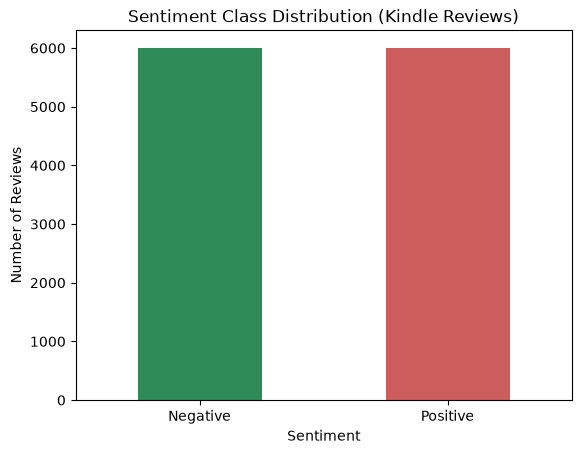

In [5]:
# Visualize class distribution
df["sentiment"].value_counts().plot(kind="bar", color=["seagreen", "indianred"])
plt.title("Sentiment Class Distribution (Kindle Reviews)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

### 4.Text Preprocessing

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to clean and preprocess a review
def text_preprocess(review):
    review = str(review).lower()  #convert review to string and make it all lowercase
    review = re.sub(r'http\S+|www\.\S+', ' ', review) #remove urls
    review = re.sub(r'[^a-zA-Z]',' ',review) #remove all except alphabets
    review = review.split() #split the cleaned text into individual words
    review = [
        lemmatizer.lemmatize(word,pos='v')
        for word in review
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(review)
df['cleaned_text'] = df['review'].apply(text_preprocess)

df[['review_id','cleaned_text','rating','sentiment']]

,review_id,cleaned_text,rating,sentiment
0,1,jace rankin may short nothing mess man haul saloon undertaker know famous bounty hunter oregon s...,3,Negative
1,2,great short read want put read one sit sex scenes great two males one female character bite surp...,5,Positive
2,3,start say first four book expect conclude center children alex younger brother argus alex friend...,3,Negative
3,4,aggie angela lansbury carry pocketbooks instead write light murder mystery lace misdirections cl...,3,Negative
4,5,expect type book library please find price right,4,Positive
...,...,...,...,...
11995,11996,valentine cupid vampire jena ian another vampire find one four friends find vampire mat half vam...,4,Positive
11996,11997,read seven book series apocalyptic adventure one favorite genres therefore series good fit enjoy...,5,Positive
11997,11998,book really cuppa situation man capture woman workplace tie sex bunch guy around turn somehow cr...,3,Negative
11998,11999,try use charge kindle even register charge completely worthless trouble send back,1,Negative


### 5.TF-IDF Vectorization:

In [7]:
vectorizer = TfidfVectorizer(ngram_range=(1,1),min_df=5)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

print('Feature matrix shape:',X.shape)
print('Vocabulary size:',len(vectorizer.vocabulary_))

Feature matrix shape: (12000, 7373)
Vocabulary size: 7373


### 6.Train/Test Split the Dataset:


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42, stratify=y)
print('Train Data Size:',X_train.shape[0])
print('Test Data Size:',X_test.shape[0])

Train Data Size: 9600
Test Data Size: 2400


### 7.Train The Model:


#### 7.1Logistic Regression Model:

In [9]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train,y_train)
lr_pred = lr_model.predict(X_test)

print('Logistic Regression Accuracy',accuracy_score(y_test,lr_pred))
print(classification_report(y_test,lr_pred))

Logistic Regression Accuracy 0.8279166666666666
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      1200
    Positive       0.82      0.84      0.83      1200

    accuracy                           0.83      2400
   macro avg       0.83      0.83      0.83      2400
weighted avg       0.83      0.83      0.83      2400



#### 7.2Navie Bayes:

In [10]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)
nb_predict=nb_model.predict(X_test)

print('Navie Bayes Accuracy:',accuracy_score(y_test,nb_predict))
print(classification_report(y_test,nb_predict))

Navie Bayes Accuracy: 0.8179166666666666
              precision    recall  f1-score   support

    Negative       0.81      0.83      0.82      1200
    Positive       0.83      0.81      0.82      1200

    accuracy                           0.82      2400
   macro avg       0.82      0.82      0.82      2400
weighted avg       0.82      0.82      0.82      2400



### Predict Unseen Reviews:

In [35]:
def predict_cleaned(cleaned_text, model=lr_model, vec=vectorizer):
    vector = vec.transform([cleaned_text])
    prediction = model.predict(vector)[0]
    confidence = model.predict_proba(vector).max()
    return prediction, round(confidence, 2)

new_df = pd.read_csv("kindle_unseen_500.csv")

new_df["cleaned_text"] = new_df["reviewText"].apply(text_preprocess)

preds, confs = zip(*new_df["cleaned_text"].apply(predict_cleaned))

new_df["predicted_category"] = preds
new_df["confidence"] = confs

new_df[['cleaned_text', 'overall', 'predicted_category', 'confidence']]

,cleaned_text,overall,predicted_category,confidence
0,struggle finish book confuse,2,Negative,0.92
1,average read nothing particularly memorable,3,Negative,0.90
2,excellent character development plot twist,5,Positive,0.67
3,write style easy follow enjoyable,4,Positive,0.80
4,story engage begin end,5,Negative,0.58
...,...,...,...,...
495,good book pace felt slow chapters,4,Negative,0.72
496,good book pace felt slow chapters,4,Negative,0.72
497,disappoint poorly edit,1,Negative,0.95
498,good book pace felt slow chapters,4,Negative,0.72
